In [12]:
%pip install azure-cosmos matplotlib seaborn pandas numpy
%pip install --upgrade azure-cosmos

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\acane\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\acane\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Import Required Libraries

In [13]:

import os
from azure.cosmos import CosmosClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

Connect to Cosmos DB

In [14]:
# Cosmos DB Configuration
COSMOS_ENDPOINT = os.getenv("COSMOS_ENDPOINT", "https://aegiscosmosdb.documents.azure.com")
COSMOS_KEY = os.getenv("COSMOS_KEY", "6Di3nSl2nSG7qitzD8SGYeXuw5rn3eUmC4fha2YswtM5R5hSet8u0hYzMMSnhVBmTfNgMJMxKAbTACDbSPsJpg==")
DATABASE_NAME = "aegisraw"  # Update with your database name
CONTAINERS_TO_AUDIT = ["openalex-works", "dtic-works"]

client = CosmosClient(COSMOS_ENDPOINT, COSMOS_KEY)
database = client.get_database_client(DATABASE_NAME)

# Initialize Cosmos client
client = CosmosClient(COSMOS_ENDPOINT, COSMOS_KEY)
database = client.get_database_client(DATABASE_NAME)

print(f"Connected to database: {DATABASE_NAME}, container: {CONTAINERS_TO_AUDIT}")

Connected to database: aegisraw, container: ['openalex-works', 'dtic-works']


Advanced Audit Query

🔍 Auditing openalex-works...
🔍 Auditing dtic-works...


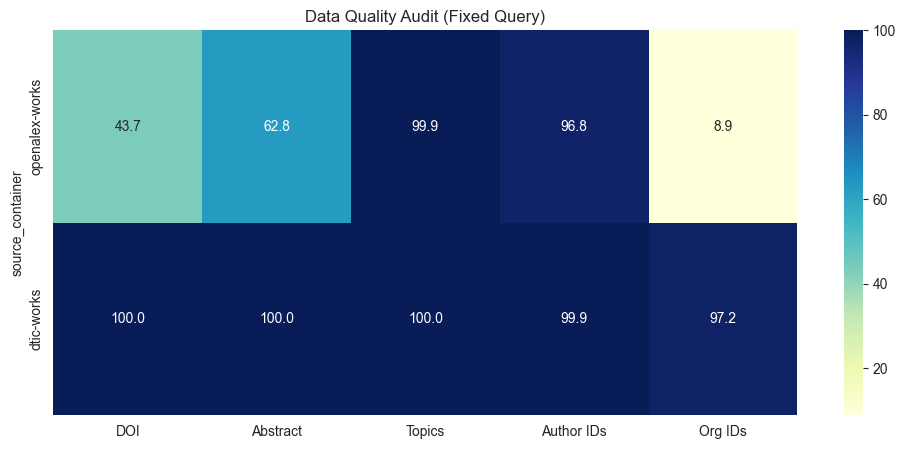

  source_container  total_records  has_doi  has_abstract  has_topics  \
0   openalex-works        1287894   562648        808191     1286550   
1       dtic-works          28071    28071         28071       28071   

   has_author_ids  has_org_ids  
0         1246552       114145  
1           28045        27289  


In [15]:
all_results = []

# Metrics to audit
metrics_to_check = {
    "has_doi": "IS_DEFINED(c.doi) OR IS_DEFINED(c.DOI)",
    "has_abstract": "IS_DEFINED(c.abstract) OR IS_DEFINED(c.abstract_inverted_index)",
    "has_topics": "(IS_DEFINED(c.topics) AND ARRAY_LENGTH(c.topics) > 0) OR (IS_DEFINED(c.keywords) AND ARRAY_LENGTH(c.keywords) > 0)",
    "has_author_ids": "EXISTS(SELECT VALUE a FROM a IN c.authors WHERE IS_DEFINED(a.researcher_id)) OR EXISTS(SELECT VALUE a FROM a IN c.authorships WHERE IS_DEFINED(a.author.id))",
    "has_org_ids": "EXISTS(SELECT VALUE o FROM o IN c.organizations WHERE IS_DEFINED(o.org_id)) OR EXISTS(SELECT VALUE a FROM a IN c.authorships WHERE EXISTS(SELECT VALUE i FROM i IN a.institutions WHERE IS_DEFINED(i.id)))"
}

for container_name in CONTAINERS_TO_AUDIT:
    print(f"🔍 Auditing {container_name}...")
    container = database.get_container_client(container_name)
    
    # Get Total Count First
    total_res = list(container.query_items("SELECT VALUE COUNT(1) FROM c", enable_cross_partition_query=True))
    total_count = total_res[0] if total_res else 0
    
    container_stats = {'source_container': container_name, 'total_records': total_count}
    
    # Get each metric individually to avoid "MultipleAggregates" error
    for metric_name, condition in metrics_to_check.items():
        query = f"SELECT VALUE COUNT(1) FROM c WHERE {condition}"
        count_res = list(container.query_items(query, enable_cross_partition_query=True))
        container_stats[metric_name] = count_res[0] if count_res else 0
        
    all_results.append(container_stats)

# --- Process and Plot ---
df = pd.DataFrame(all_results)
if not df.empty:
    for m in metrics_to_check.keys():
        df[f'{m}_pct'] = (df[m] / df['total_records']) * 100

    plot_df = df.set_index('source_container')[[c for c in df.columns if '_pct' in c]]
    plot_df.columns = ['DOI', 'Abstract', 'Topics', 'Author IDs', 'Org IDs']
    
    plt.figure(figsize=(12, 5))
    sns.heatmap(plot_df, annot=True, cmap='YlGnBu', fmt=".1f")
    plt.title('Data Quality Audit (Fixed Query)')
    plt.show()
    
    print(df[['source_container', 'total_records'] + list(metrics_to_check.keys())])

Data Processing and Percentage Calculation

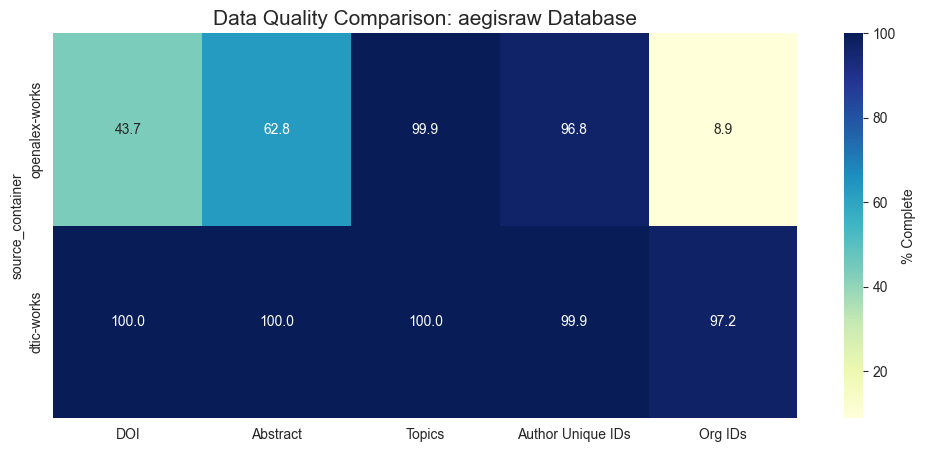

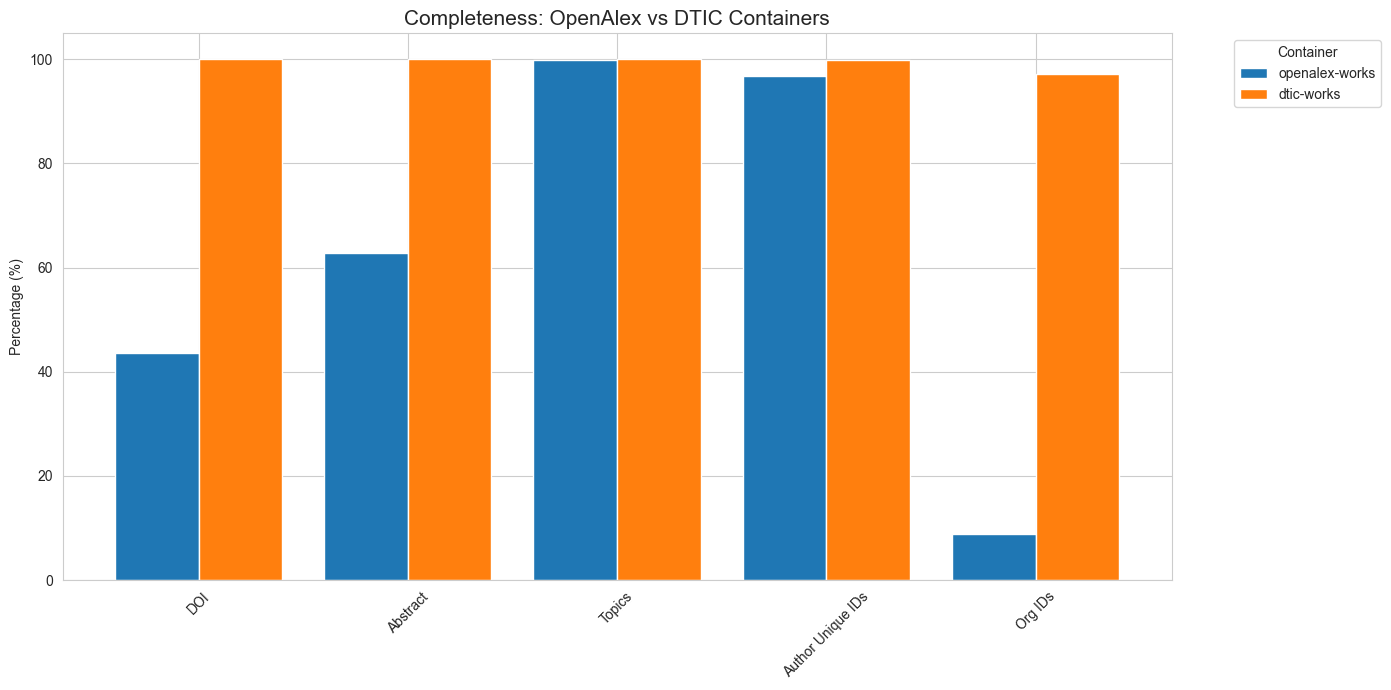


--- Summary Table ---
  source_container  total_records  has_doi  has_abstract  has_topics  \
0   openalex-works        1287894   562648        808191     1286550   
1       dtic-works          28071    28071         28071       28071   

   has_author_ids  has_org_ids  
0         1246552       114145  
1           28045        27289  


In [17]:
df = pd.DataFrame(all_results)

if not df.empty:
    # 1. Update this list to match the dictionary keys exactly
    metrics = ['has_doi', 'has_abstract', 'has_topics', 'has_author_ids', 'has_org_ids']
    
    # Calculate percentages for comparison
    for m in metrics:
        # Note: Using 'total_records' to match the refactored loop
        df[f'{m}_pct'] = (df[m] / df['total_records']) * 100

    # 2. Match these 5 names to the 5 metrics above
    plot_df = df.set_index('source_container')[[c for c in df.columns if '_pct' in c]]
    plot_df.columns = ['DOI', 'Abstract', 'Topics', 'Author Unique IDs', 'Org IDs']

    # --- 4. VISUALIZATIONS ---
    sns.set_style("whitegrid")
    
    # Heatmap
    plt.figure(figsize=(12, 5))
    sns.heatmap(plot_df, annot=True, cmap='YlGnBu', fmt=".1f", cbar_kws={'label': '% Complete'})
    plt.title(f'Data Quality Comparison: {DATABASE_NAME} Database', fontsize=15)
    plt.show()

    # Bar Chart comparison
    plot_df.T.plot(kind='bar', figsize=(14, 7), width=0.8)
    plt.title('Completeness: OpenAlex vs DTIC Containers', fontsize=15)
    plt.ylabel('Percentage (%)')
    plt.ylim(0, 105)
    plt.legend(title="Container", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("\n--- Summary Table ---")
    print(df[['source_container', 'total_records'] + metrics])
else:
    print("No data retrieved. Check container names and connectivity.")

The Topic Strength: Almost every record (99.9%) has a topic. OpenAlex uses an AI classifier to tag works, so even if a paper is missing a DOI, it usually still has a topic.

The DOI Gap: Only 43.7% of these records have a DOI. This means over half of the records might be "grey literature," older reports, or datasets that aren't indexed in traditional journals.

The Organization Crisis: Only 8.8% of these records have a persistent Org ID (like a ROR or GRID ID). This is your biggest hurdle.

While there is an abundance of data here, it is very difficult to do "Institutional Analysis" (e.g., "Show me everything from MIT") because the IDs are missing for 90% of the works.

Missing Data Report Per Attribute Per Source

In [ ]:
# Create the Final Comparison Report
report_df = pd.DataFrame()
report_df['Source'] = df['source_container'].replace({'openalex-works': 'OpenAlex', 'dtic-works': 'DTIC'})
report_df['Total Records'] = df['total_records'].apply(lambda x: f"{x:,}")

# Logic to calculate missing values 
# (This looks at the columns: has_doi, has_abstract, has_topics, has_author_ids, has_org_ids)
def get_missing(row, key):
    missing = row['total_records'] - row[key]
    pct = (missing / row['total_records']) * 100
    return f"{missing:,} ({pct:.1f}%)"

# --- MAPPED TO YOUR RECENT AUDIT RESULTS ---
report_df['DOI Missing'] = df.apply(lambda r: get_missing(r, 'has_doi'), axis=1)
report_df['Topics Missing'] = df.apply(lambda r: get_missing(r, 'has_topics'), axis=1)

report_df['Orgs Missing'] = df.apply(lambda r: get_missing(r, 'has_org_ids'), axis=1) 

report_df['Abstract Missing'] = df.apply(lambda r: get_missing(r, 'has_abstract'), axis=1)
report_df['Author IDs Missing'] = df.apply(lambda r: get_missing(r, 'has_author_ids'), axis=1)

print("--- FINAL DATA QUALITY: MISSING ATTRIBUTE REPORT ---")
display(report_df)

--- FINAL DATA QUALITY: MISSING ATTRIBUTE REPORT ---


,Source,Total Records,DOI Missing,Topics Missing,Orgs Missing,Abstract Missing,Author IDs Missing
0,OpenAlex,"1,287,894","725,246 (56.3%)","1,344 (0.1%)","1,173,749 (91.1%)","479,703 (37.2%)","41,342 (3.2%)"
1,DTIC,"28,071",0 (0.0%),0 (0.0%),782 (2.8%),0 (0.0%),26 (0.1%)


Missing Data Visualization

<Figure size 1400x700 with 0 Axes>

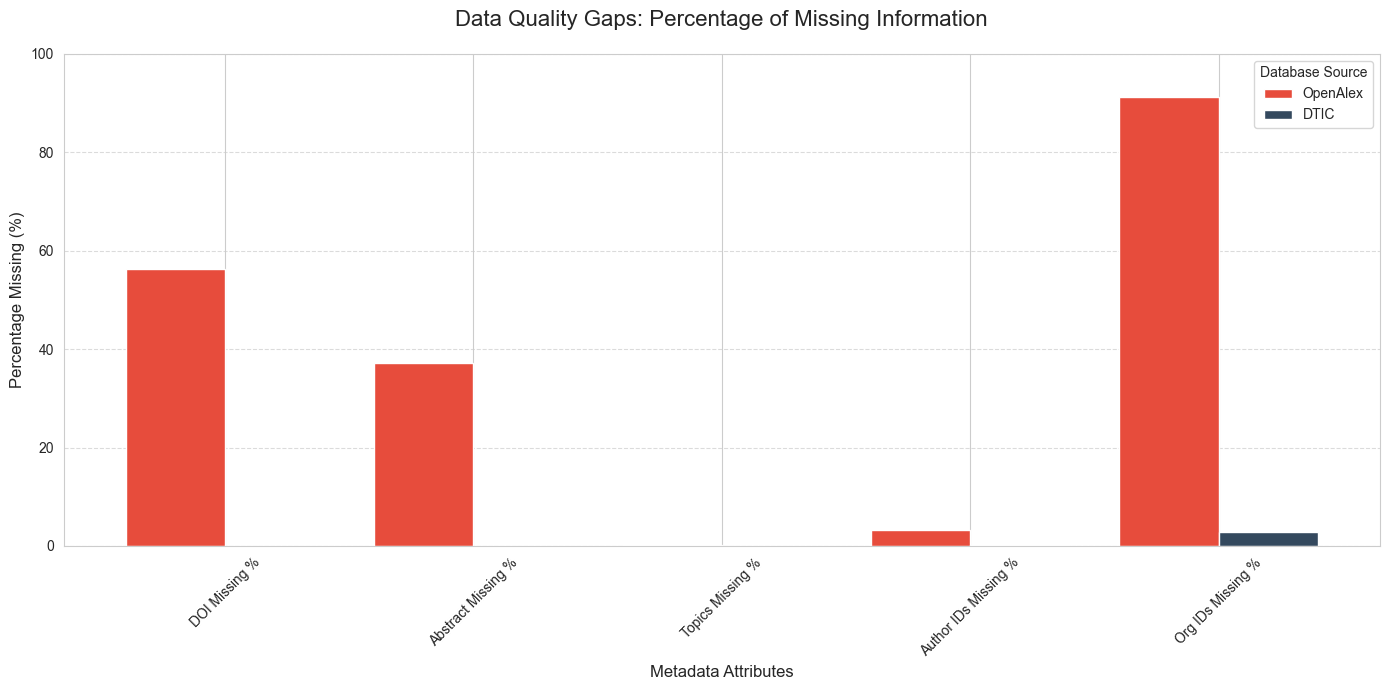

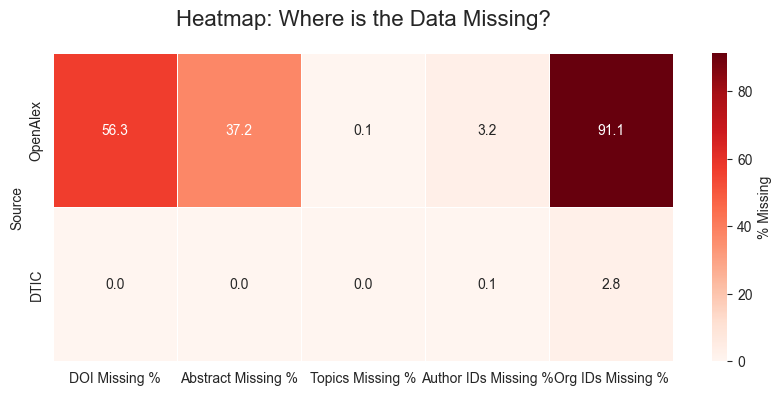

In [21]:
# 1. Prepare the 'Missing' Dataframe for plotting
missing_plot_df = pd.DataFrame()
missing_plot_df['Source'] = df['source_container'].replace({'openalex-works': 'OpenAlex', 'dtic-works': 'DTIC'})

# Calculate missing percentages for the plot
metrics_map = {
    'has_doi': 'DOI',
    'has_abstract': 'Abstract',
    'has_topics': 'Topics',
    'has_author_ids': 'Author IDs',
    'has_org_ids': 'Org IDs'
}

for raw_col, clean_name in metrics_map.items():
    missing_plot_df[f'{clean_name} Missing %'] = ((df['total_records'] - df[raw_col]) / df['total_records']) * 100

# Set index for plotting
missing_plot_df.set_index('Source', inplace=True)

# --- 2. Visualization A: The Gap Bar Chart ---
sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

# We transpose to group by Attribute
missing_plot_df.T.plot(kind='bar', figsize=(14, 7), color=['#e74c3c', '#34495e'], width=0.8)

plt.title('Data Quality Gaps: Percentage of Missing Information', fontsize=16, pad=20)
plt.ylabel('Percentage Missing (%)', fontsize=12)
plt.xlabel('Metadata Attributes', fontsize=12)
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.legend(title='Database Source', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- 3. Visualization B: Heatmap of Data Holes ---
plt.figure(figsize=(10, 4))
sns.heatmap(missing_plot_df, annot=True, cmap='Reds', fmt=".1f", linewidths=.5, cbar_kws={'label': '% Missing'})
plt.title('Heatmap: Where is the Data Missing?', fontsize=16, pad=20)
plt.show()